# 09 Network Relationship Analysis

Build relationship network outputs and meaningful business insight charts.


In [1]:
import warnings
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


## 1) Project Paths


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

from utils.utils import ensure_project_dirs

ensure_project_dirs()

KPI_PATH = PROJECT_ROOT / "data" / "processed" / "kpi_dataset.csv"

OUTPUTS_DIR = NOTEBOOKS_DIR / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)


## 2) Required Columns


In [3]:
REQUIRED_COLUMNS = [
    "business_name",
    "sector",
    "post_type",
    "language",
    "engagement",
    "engagement_rate",
]

RELATIONSHIPS = [
    ("business_name", "sector", "business_to_sector", "Business", "Sector"),
    ("business_name", "post_type", "business_to_post_type", "Business", "Post Type"),
    ("business_name", "language", "business_to_language", "Business", "Language"),
    ("sector", "post_type", "sector_to_post_type", "Sector", "Post Type"),
    ("post_type", "engagement_level", "post_type_to_engagement_level", "Post Type", "Engagement Level"),
    ("language", "engagement_level", "language_to_engagement_level", "Language", "Engagement Level"),
    ("sector", "engagement_level", "sector_to_engagement_level", "Sector", "Engagement Level"),
]

TYPE_PREFIX = {
    "Business": "business",
    "Sector": "sector",
    "Post Type": "post_type",
    "Language": "language",
    "Engagement Level": "engagement_level",
}


## 3) Helper Functions


In [4]:
def normalize_text_value(value):
    if pd.isna(value):
        return ""
    txt = str(value).strip()
    txt = re.sub(r"\s+", " ", txt)
    return txt.lower()


def make_node_id(node_type, label):
    prefix = TYPE_PREFIX[node_type]
    return f"{prefix}:{label}"


def standardize_existing_engagement_level(series):
    mapper = {
        "low": "low_engagement",
        "medium": "medium_engagement",
        "high": "high_engagement",
        "low_engagement": "low_engagement",
        "medium_engagement": "medium_engagement",
        "high_engagement": "high_engagement",
    }

    return series.astype(str).str.strip().str.lower().map(mapper)


def label_by_quantiles(values, low_q, high_q):
    low_thr = values.quantile(low_q)
    high_thr = values.quantile(high_q)

    out = pd.Series("medium_engagement", index=values.index)
    out.loc[values <= low_thr] = "low_engagement"
    out.loc[values >= high_thr] = "high_engagement"

    return out


def label_by_fixed_rate(values, low_thr=0.03, high_thr=0.08):
    out = pd.Series("medium_engagement", index=values.index)
    out.loc[values < low_thr] = "low_engagement"
    out.loc[values >= high_thr] = "high_engagement"

    return out


def build_nodes_and_edges(df, min_weight=1):
    edge_frames = []
    node_parts = []

    for source_col, target_col, rel_name, source_type, target_type in RELATIONSHIPS:
        rel_df = (
            df[[source_col, target_col]]
            .dropna(subset=[source_col, target_col])
            .groupby([source_col, target_col], as_index=False)
            .size()
            .rename(columns={"size": "weight"})
        )

        rel_df = rel_df[rel_df["weight"] >= min_weight].copy()

        if rel_df.empty:
            continue

        rel_df["source"] = rel_df[source_col].map(
            lambda v: make_node_id(source_type, v)
        )

        rel_df["target"] = rel_df[target_col].map(
            lambda v: make_node_id(target_type, v)
        )

        rel_df["relationship"] = rel_name

        edge_frames.append(
            rel_df[["source", "target", "relationship", "weight"]]
        )

        src_nodes = (
            rel_df[[source_col]]
            .drop_duplicates()
            .rename(columns={source_col: "label"})
        )
        src_nodes["type"] = source_type
        src_nodes["id"] = src_nodes["label"].map(
            lambda v: make_node_id(source_type, v)
        )

        tgt_nodes = (
            rel_df[[target_col]]
            .drop_duplicates()
            .rename(columns={target_col: "label"})
        )
        tgt_nodes["type"] = target_type
        tgt_nodes["id"] = tgt_nodes["label"].map(
            lambda v: make_node_id(target_type, v)
        )

        node_parts.extend([
            src_nodes[["id", "label", "type"]],
            tgt_nodes[["id", "label", "type"]],
        ])

    edges = (
        pd.concat(edge_frames, ignore_index=True)
        if edge_frames
        else pd.DataFrame(columns=["source", "target", "relationship", "weight"])
    )

    nodes = (
        pd.concat(node_parts, ignore_index=True)
        .drop_duplicates()
        .sort_values(["type", "label"])
        .reset_index(drop=True)
        if node_parts
        else pd.DataFrame(columns=["id", "label", "type"])
    )

    return nodes, edges


def evaluate_method(df, method_name):
    nodes, edges = build_nodes_and_edges(df, min_weight=1)

    counts = (
        df["engagement_level"]
        .value_counts(dropna=False)
        .reindex(
            ["low_engagement", "medium_engagement", "high_engagement"],
            fill_value=0,
        )
    )

    props = counts / max(len(df), 1)
    l1_dist = np.abs(props - (1 / 3)).sum()
    balance_score = 1 - (l1_dist / (4 / 3))

    relationship_coverage = (
        edges["relationship"].nunique() / len(RELATIONSHIPS)
        if len(RELATIONSHIPS)
        else 0
    )

    final_score = 0.7 * balance_score + 0.3 * relationship_coverage

    return {
        "method": method_name,
        "rows": len(df),
        "low_count": int(counts["low_engagement"]),
        "medium_count": int(counts["medium_engagement"]),
        "high_count": int(counts["high_engagement"]),
        "balance_score": float(balance_score),
        "relationship_coverage": float(relationship_coverage),
        "score": float(final_score),
        "nodes": int(len(nodes)),
        "edges": int(len(edges)),
    }


## 4) Load and Clean Dataset


In [5]:
df_raw = pd.read_csv(KPI_PATH)

print("Using KPI dataset:", KPI_PATH)
print("Input dataset shape:", df_raw.shape)

missing_required = [col for col in REQUIRED_COLUMNS if col not in df_raw.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df = df_raw.copy()

df["business_name"] = df["business_name"].map(normalize_text_value)
df = df[df["business_name"] != ""].copy()

for col in ["sector", "post_type", "language"]:
    df[col] = df[col].fillna("unknown").map(normalize_text_value)
    df.loc[df[col] == "", col] = "unknown"

df["engagement"] = pd.to_numeric(df["engagement"], errors="coerce").fillna(0)
df["engagement_rate"] = pd.to_numeric(df["engagement_rate"], errors="coerce")

if df["engagement_rate"].isna().all():
    df["engagement_rate"] = 0
else:
    df["engagement_rate"] = df["engagement_rate"].fillna(
        df["engagement_rate"].median()
    )

print("Cleaned dataset shape:", df.shape)


Using KPI dataset: C:\Users\hanai\marketing\data\processed\kpi_dataset.csv
Input dataset shape: (656, 43)
Cleaned dataset shape: (656, 43)


## 5) Engagement Level Method Selection


In [6]:
methods = {}

if "engagement_level" in df.columns:
    existing = standardize_existing_engagement_level(df["engagement_level"])

    if existing.notna().mean() >= 0.9:
        m1 = df.copy()
        m1["engagement_level"] = existing.fillna("medium_engagement")
        methods["existing_engagement_level"] = m1

m2 = df.copy()
m2["engagement_level"] = label_by_quantiles(
    m2["engagement_rate"],
    low_q=1 / 3,
    high_q=2 / 3,
)
methods["quantile_33_33_33"] = m2

m3 = df.copy()
m3["engagement_level"] = label_by_fixed_rate(
    m3["engagement_rate"],
    low_thr=0.03,
    high_thr=0.08,
)
methods["fixed_rate_0.03_0.08"] = m3

m4 = df.copy()
m4["engagement_level"] = label_by_quantiles(
    m4["engagement_rate"],
    low_q=0.25,
    high_q=0.75,
)
methods["bottom25_mid50_top25"] = m4

experiment_rows = []

for method_name, method_df in methods.items():
    experiment_rows.append(
        evaluate_method(method_df, method_name)
    )

experiments_df = (
    pd.DataFrame(experiment_rows)
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

chosen_method = experiments_df.iloc[0]["method"]
final_df = methods[chosen_method].copy()

print("Chosen threshold method:", chosen_method)


Chosen threshold method: existing_engagement_level


## 6) Build Final Network


In [7]:
MIN_WEIGHT = 2

network_nodes, network_edges = build_nodes_and_edges(
    final_df,
    min_weight=MIN_WEIGHT,
)

top_edges = (
    network_edges
    .sort_values("weight", ascending=False)
    .head(10)
    .copy()
)


## 7) Save Important CSV Outputs


In [9]:
network_nodes.to_csv(
    OUTPUTS_DIR / "network_nodes.csv",
    index=False,
)

network_edges.to_csv(
    OUTPUTS_DIR / "network_edges.csv",
    index=False,
)

experiments_df.to_csv(
    OUTPUTS_DIR / "network_threshold_experiments.csv",
    index=False,
)

top_edges.to_csv(
    OUTPUTS_DIR / "top10_network_relationships.csv",
    index=False,
)

summary_rows = [
    {"metric": "input_rows", "value": len(df_raw)},
    {"metric": "cleaned_rows", "value": len(final_df)},
    {"metric": "chosen_threshold_method", "value": chosen_method},
    {"metric": "min_edge_weight", "value": MIN_WEIGHT},
    {"metric": "nodes_count", "value": len(network_nodes)},
    {"metric": "edges_count", "value": len(network_edges)},
]

engagement_dist = (
    final_df["engagement_level"]
    .value_counts()
    .reindex(
        ["low_engagement", "medium_engagement", "high_engagement"],
        fill_value=0,
    )
)

for level, count in engagement_dist.items():
    summary_rows.append(
        {
            "metric": f"engagement_level_{level}",
            "value": int(count),
        }
    )

network_summary = pd.DataFrame(summary_rows)

network_summary.to_csv(
    OUTPUTS_DIR / "network_summary.csv",
    index=False,
)


## 8) Save Meaningful Charts


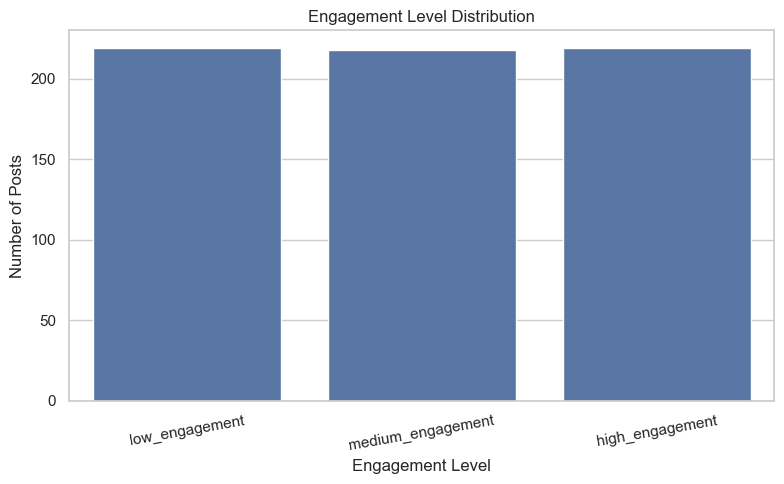

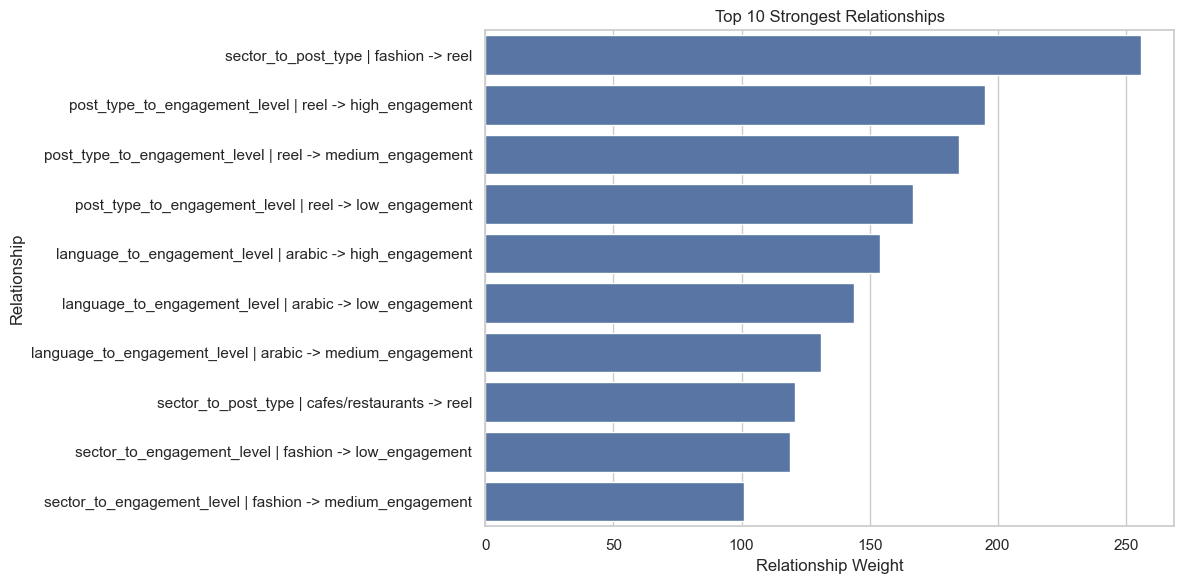

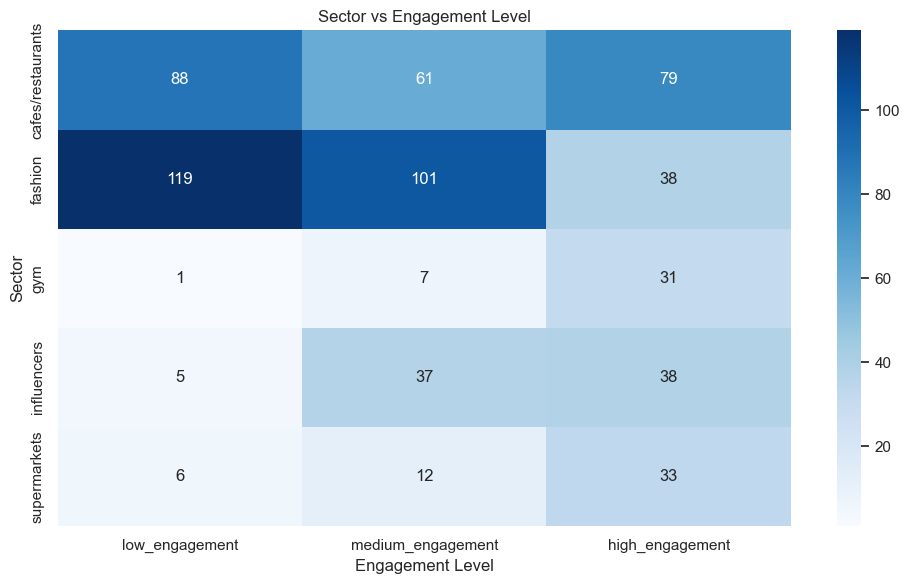

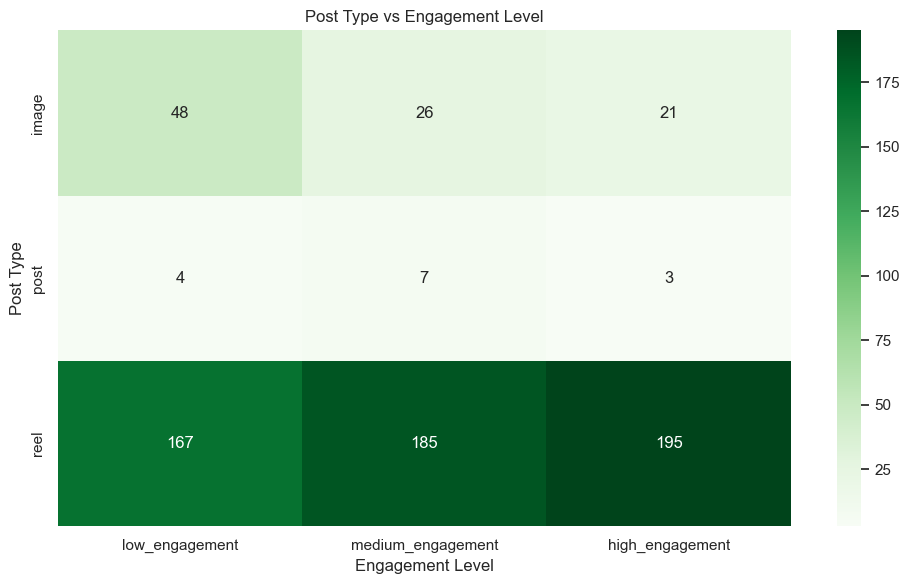

In [10]:
# Chart 1: Engagement Level Distribution
plt.figure(figsize=(8, 5))

sns.barplot(
    x=engagement_dist.index,
    y=engagement_dist.values,
)

plt.title("Engagement Level Distribution")
plt.xlabel("Engagement Level")
plt.ylabel("Number of Posts")
plt.xticks(rotation=10)
plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR / "network_engagement_level_distribution.png"
)

plt.show()

# Chart 2: Top 10 Strongest Relationships
plot_edges = top_edges.copy()

plot_edges["edge_label"] = (
    plot_edges["relationship"]
    + " | "
    + plot_edges["source"].str.split(":", n=1).str[1]
    + " -> "
    + plot_edges["target"].str.split(":", n=1).str[1]
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_edges,
    y="edge_label",
    x="weight",
)

plt.title("Top 10 Strongest Relationships")
plt.xlabel("Relationship Weight")
plt.ylabel("Relationship")
plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR / "network_top10_strongest_relationships.png"
)

plt.show()

# Chart 3: Sector x Engagement Level Heatmap
sector_engagement = pd.crosstab(
    final_df["sector"],
    final_df["engagement_level"],
)

sector_engagement = sector_engagement.reindex(
    columns=["low_engagement", "medium_engagement", "high_engagement"],
    fill_value=0,
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    sector_engagement,
    annot=True,
    fmt="d",
    cmap="Blues",
)

plt.title("Sector vs Engagement Level")
plt.xlabel("Engagement Level")
plt.ylabel("Sector")
plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR / "network_sector_engagement_heatmap.png"
)

plt.show()

# Chart 4: Post Type x Engagement Level Heatmap
post_type_engagement = pd.crosstab(
    final_df["post_type"],
    final_df["engagement_level"],
)

post_type_engagement = post_type_engagement.reindex(
    columns=["low_engagement", "medium_engagement", "high_engagement"],
    fill_value=0,
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    post_type_engagement,
    annot=True,
    fmt="d",
    cmap="Greens",
)

plt.title("Post Type vs Engagement Level")
plt.xlabel("Engagement Level")
plt.ylabel("Post Type")
plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR / "network_post_type_engagement_heatmap.png"
)

plt.show()


## 9) Final Summary


In [11]:
print("Network Relationship Analysis completed successfully.")
print()
print("Saved outputs to:")
print(OUTPUTS_DIR)
print()
print("Generated CSV files:")
print("- network_nodes.csv")
print("- network_edges.csv")
print("- network_summary.csv")
print("- network_threshold_experiments.csv")
print("- top10_network_relationships.csv")
print()
print("Generated chart files:")
print("- network_engagement_level_distribution.png")
print("- network_top10_strongest_relationships.png")
print("- network_sector_engagement_heatmap.png")
print("- network_post_type_engagement_heatmap.png")
print()
print("Chosen threshold method:", chosen_method)
print("Min edge weight:", MIN_WEIGHT)
print("Number of nodes:", len(network_nodes))
print("Number of edges:", len(network_edges))


Network Relationship Analysis completed successfully.

Saved outputs to:
C:\Users\hanai\marketing\notebooks\outputs

Generated CSV files:
- network_nodes.csv
- network_edges.csv
- network_summary.csv
- network_threshold_experiments.csv
- top10_network_relationships.csv

Generated chart files:
- network_engagement_level_distribution.png
- network_top10_strongest_relationships.png
- network_sector_engagement_heatmap.png
- network_post_type_engagement_heatmap.png

Chosen threshold method: existing_engagement_level
Min edge weight: 2
Number of nodes: 73
Number of edges: 240
